# UFM Relock Workflow
This notebook is to walks through the steps of how to get from approaching a system that is in an unknown state but which already has an optimized `dev_cfg` file generated by a smurf expert user (as described in the `ufm_setup_workflow`). We will walk through step by step in this notebook but in the near future we will move to using the sodetlib [uxm_relock](https://github.com/simonsobs/sodetlib/blob/uxm_setup/scratch/yuhanw/uxm_relock.py) function which is currently under PR review but should be available to use and demo in the next ~1 week.

### Standard Imports

In [1]:
from sodetlib.det_config import DetConfig
import sodetlib.smurf_funcs.smurf_ops as so
import sodetlib.smurf_funcs.optimize_params as op
import sodetlib.util as su
from importlib import reload
from tqdm import tqdm
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

from scipy.signal import welch

# Warnings are annoying
import warnings
warnings.filterwarnings("ignore")

### Get dev_cfg and pysmurf object
See setup notebook, same steps

In [2]:
cfg = DetConfig()
cfg.load_config_files(slot=2)
S = cfg.get_smurf_control(apply_dev_configs=False, make_logfile=True)

### Check Amplifiers
First just check that amplifier biases are still at correct value. These values are ok for SAT1 given our offset current (typical system Id for hemt should be closer to 8mA).

In [3]:
S.get_amplifier_biases()

{'hemt_Vg': -1.9999987199999998,
 'hemt_Id': 10.512304699999998,
 '50K_Vg': -0.649997,
 '50K_Id': 13.53515625}

### Load Tune & Relock
Next load the tune file stored in your device config and `relock` which just turns on tones at the frequencies set in the tune file and sets your eta parameters to those in the tune file. Following a `relock` the serial algorithms `run_serial_gradient_descent` and `run_serial_eta_scan` must be run because the frequencies in the tune file are too far off to get good tracking results (you're on the resonator but not on the most sensitive part of the resonator) and these algorithms will fix that.

All of these functions except for `load_tune` are run on a per band basis so we have to loop through bands to run these. Since these functions take a pretty long time we can add a step between loading tune and running the per band functions which just identifies which bands have resonators in your tune file. For a UFM this should be all bands but in other assemblies you can speed things up by skipping unused bands.

In [16]:
S.load_tune(cfg.dev.exp['tunefile'])
active_bands = []
for b in range(8):
    if 'resonances' in S.freq_resp[b].keys():
        active_bands.append(b)
print(active_bands)

[0, 1, 2, 3, 4, 5, 6, 7]


Note that since we are using the UFM we have all bands but instead if we were to do the same thing for a tunefile that came from an SPB you would see less active bands:

In [17]:
S.load_tune('/data/smurf_data/tune/1624671253_tune.npy')
active_bands = []
for b in range(8):
    if 'resonances' in S.freq_resp[b].keys():
        active_bands.append(b)
print(active_bands)

[2, 6]


I'll run the `load_tune` cell contents again so that we make sure we're using the UFM tune file and not the SPB one that we just used to demo restricted bands and this time we'll also run the relock. Additionally note that I'm making sure that my attenuators and drive powers are also set to the values in my device config file

In [19]:
S.load_tune(cfg.dev.exp['tunefile'])
active_bands = []
for b in range(8):
    if 'resonances' in S.freq_resp[b].keys():
        active_bands.append(b)
for b in active_bands:
    S.set_att_uc(b,cfg.dev.bands[b]['uc_att'])
    S.set_att_dc(b,cfg.dev.bands[b]['dc_att'])
    S.relock(b,tone_power=cfg.dev.bands[b]['drive'])
    S.run_serial_gradient_descent(b)
    S.run_serial_eta_scan(b)

### Tracking Setup
Next we need to run `tracking_setup` per band (so we could really put this step in the previous for loop through the active bands but I separated it out here for clarity. We will run it using the `tracking_quality` function in `sodetlib` which runs the `pysmurf` `tracking_setup` function in `pysmurf` but loads your `tracking_setup` arguments (abbreviated `tkwargs` for tracking keyword arguments) from your device config (as demo-ed in the setup notebook). It also outputs an $r^2$ metric of tracking quality which can be used as a first cut on bad channels (additional cuts may be needed based on the per channel noise PSDs).

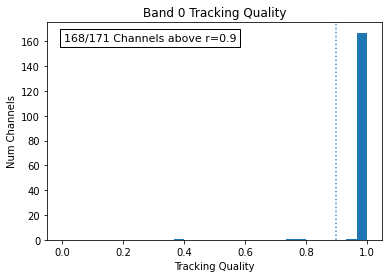

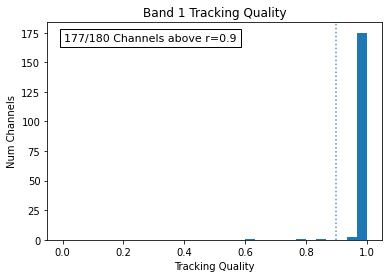

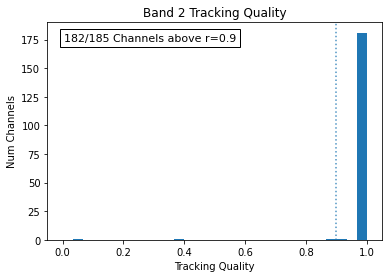

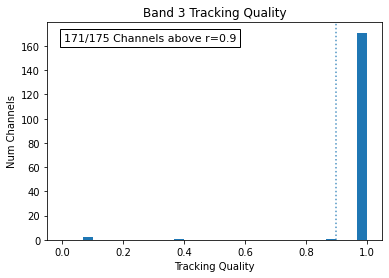

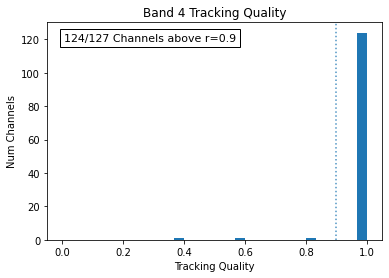

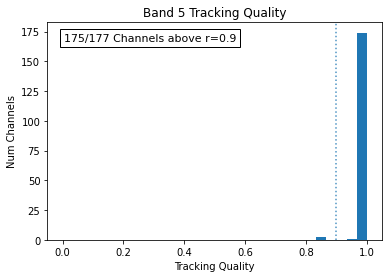

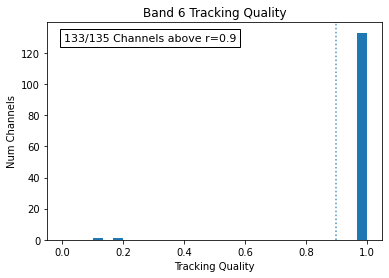

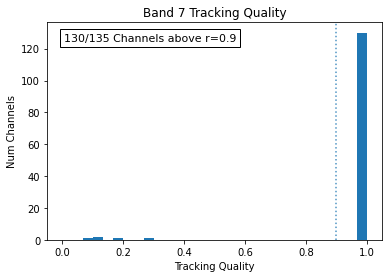

In [21]:
for b in active_bands:
    r2s, _, _, _ = so.tracking_quality(S, cfg, b, show_plots=True)
    asa = S.get_amplitude_scale_array(b)
    asa[r2s < 0.95] = 0
    S.set_amplitude_scale_array(b, asa)

### Check Noise Levels
Lastly, you can take a short data stream (<=30 seconds) and plot the distribution of white noise levels to make sure that they aren't blown up (the best indication that your setup/relock steps failed). Here we used the `take_g3_data` and `load_session` functions which saves data to disk in 3g format, returns a session id which is used to load the g3 data into an axis manager and use functions in `sotodlib` or `sodetlib` that take axis managers as inputs (this was demo-ed in the setup notebook look there for more details on g3

In our case with this assembly and detectors in a superconducting state median noise per band between ~100-250pA/$\sqrt{Hz}$ with the lower bands typically a bit lower than the higher bands (due to more degraded Qs in the higher bands) is about right so at this point we are good to proceed with streaming data and performing and further testing.

100%|██████████| 1/1 [00:00<00:00,  6.92it/s]


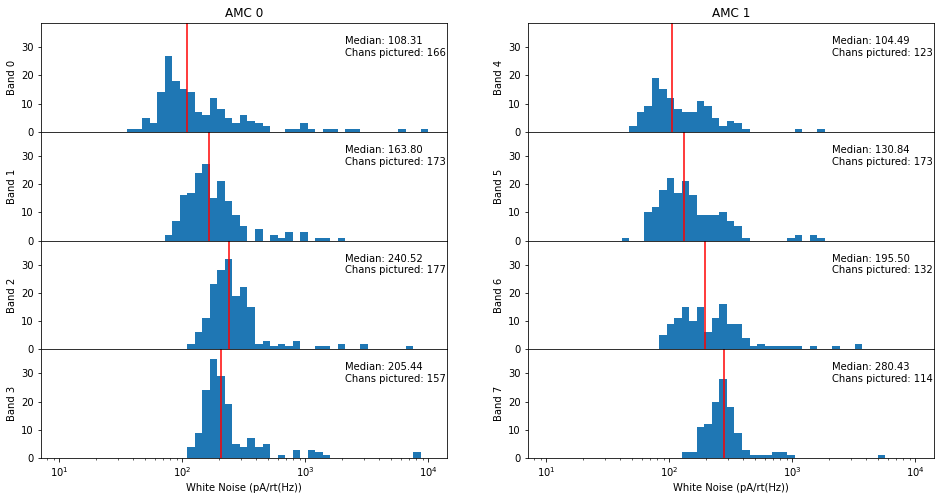

In [22]:
sid = so.take_g3_data(S, 30, make_freq_mask=False, tag='noise')
am = so.load_session(cfg, sid)
fig, axes = so.plot_band_noise(am, nbins=50)